# Anomaly Explanation and RCA Chatbot with Gemini AI Integration

This notebook enriches the ML detections of the Multimodal RCA Engine with the
**Google Gemini 2.0 Flash** model to produce natural-language explanations, comprehensive
remediation plans, and executive reports.

| Step | Topic |
|------|------|
| 1 | Environment setup and API key configuration |
| 2 | Gemini connection and model test |
| 3 | ML pipeline — anomaly detection and RCA |
| 4 | Anomaly explanation (natural language) |
| 5 | Expanded remediation plan |
| 6 | Log data interpretation |
| 7 | RCA Chatbot — free-text question answering |
| 8 | Comprehensive executive summary report |
| 9 | Chart — combined Gemini + ML results dashboard |

## 1 — Environment Setup

### Required Packages
```
pip install google-generativeai python-dotenv
```

### API Key Configuration
Create a `.env` file in the project root directory:
```
GEMINI_API_KEY=your_api_key_here
```
> Important: never write the API key inside the code or push it to git.
> The `.env` file is already excluded by `.gitignore`.

In [1]:
import sys, os, json, warnings, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import datetime
from collections import defaultdict

warnings.filterwarnings('ignore')
sys.path.insert(0, r"d:\multimodal-rca-engine")

# Read the API key from the .env file
from dotenv import load_dotenv
load_dotenv(Path(r"d:\multimodal-rca-engine\.env"))

import google.generativeai as genai
from models.data_loader import MultimodalDataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

print(f"google-generativeai : {genai.__version__}")
print(f"XGBoost             : {xgb.__version__}")
print("All libraries loaded.")

google-generativeai : 0.8.5
XGBoost             : 3.0.5
All libraries loaded.


## 2 — Gemini Connection and Model Test

We connect to the Gemini 2.0 Flash model by reading the API key from the environment variable.
We verify the connection works with a simple test query.

In [2]:
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY', '')

if not GEMINI_API_KEY:
    raise ValueError(
        "API key not found.\n"
        "Add it to d:/multimodal-rca-engine/.env:\n"
        "  GEMINI_API_KEY=your_key_here"
    )

genai.configure(api_key=GEMINI_API_KEY)
gemini = genai.GenerativeModel('gemini-3.5-flash')

import time as _time

def safe_generate(prompt, max_retries=8, pace=5):
    """Call Gemini with retry/backoff to respect free-tier rate limits."""
    for attempt in range(max_retries):
        try:
            resp = gemini.generate_content(prompt, request_options={'timeout': 600})
            _time.sleep(pace)  # pace requests to stay under the per-minute quota
            return resp.text.strip()
        except Exception as e:
            if attempt == max_retries - 1:
                raise
            wait = 35
            print(f"  [retry {attempt+1}/{max_retries}] API rate/limit error, waiting {wait}s...")
            _time.sleep(wait)

# Connection test
print("Gemini connection successful.")
print(f"Model response: {safe_generate('What is infrastructure anomaly detection? Explain in one sentence in English.')}")

Gemini connection successful.


Model response: **Infrastructure anomaly detection** is the process of continuously monitoring IT and physical systems to identify unusual patterns or behaviors that deviate from expected baselines, helping to prevent system failures, performance issues, or security threats.


### Gemini Helper Functions

The following functions enrich the ML detections with Gemini.

In [3]:
def gemini_explain_anomaly(sc_info: dict, risk: str, sla: str) -> str:
    """Produce a natural-language explanation for an anomaly."""
    prompt = f"""
You are a senior DevOps/SRE engineer. For the infrastructure anomaly below, write a clear and
constructive explanation in English for the system administrator. Explain the jargon, state the
operational impact of the risk, and emphasize why it is urgent.
Write 3-4 flowing sentences (not bullet points).

DETECTION:
- Scenario     : {sc_info.get('id','?')} - {sc_info.get('name', '')}
- Layer        : {sc_info.get('layer_name','')}
- Root Cause   : {sc_info.get('root_cause','')}
- Anomaly Type : {sc_info.get('anomaly_type','')}
- Metrics      : {', '.join(sc_info.get('detection_params',[]))}
- Risk Score   : {risk}
- Response SLA : {sla}
"""
    return safe_generate(prompt)


def gemini_expand_remediation(sc_info: dict) -> str:
    """Expand the base remediation steps and add commands."""
    steps = "\n".join(f"  - {s}" for s in sc_info.get('remediation', []))
    prompt = f"""
You are a senior SRE engineer. Expand the base remediation steps given for the anomaly below.
For each step:
1) State clearly what to do
2) Write the Linux/Kubernetes commands or procedure
3) State which risk it mitigates
4) Add a verification criterion

Write it as a numbered list in Markdown format.

ANOMALY: {sc_info.get('name','')} — {sc_info.get('layer_name','')} layer
Root Cause: {sc_info.get('root_cause','')}
Severity: {sc_info.get('severity','')}

BASE STEPS:
{steps}
"""
    return safe_generate(prompt)


def gemini_analyze_logs(log_features: dict, sc_id: str) -> str:
    """Interpret the log feature vector."""
    feats = "\n".join(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}"
                     for k, v in log_features.items())
    prompt = f"""
The log metrics below were taken from a system where the '{sc_id}' anomaly scenario was detected.
Interpret these numerical values: which are abnormal, why they are dangerous, and what the operational impact is.
Write a concise 2-3 sentence technical interpretation in English.

LOG METRICS:
{feats}
"""
    return safe_generate(prompt)


def gemini_chat(question: str, context: dict = None) -> str:
    """Free-text question answering in the context of the RCA Engine."""
    ctx = ""
    if context:
        ctx = f"\n\nCURRENT DETECTION CONTEXT:\n{json.dumps(context, ensure_ascii=False, indent=2)}"
    prompt = (
        "You are an AI assistant for the Multimodal RCA Engine. "
        "You specialize in infrastructure anomaly detection and SRE topics. "
        "Give concise, clear, and actionable answers in English."
        + ctx
        + f"\n\nQUESTION: {question}"
    )
    return safe_generate(prompt)


def gemini_full_report(results: list) -> str:
    """Produce an executive summary report from all diagnosis results."""
    anomalies = [r for r in results if r.get('is_anomaly')]
    normals   = [r for r in results if not r.get('is_anomaly')]
    sev_cnt   = defaultdict(int)
    for r in anomalies:
        sev_cnt[r.get('severity', '?')] += 1
    sc_list = "\n".join(
        f"  - {r.get('scenario_id','?')} ({r.get('sc_info',{}).get('layer_name','?')}): "
        f"{r.get('sc_info',{}).get('name','?')} [{r.get('severity','?')}]"
        for r in anomalies[:15]
    )
    prompt = f"""
You are a senior SRE engineer. Write a comprehensive Markdown report in English to present the
infrastructure diagnosis session below to management. List the issues in priority order, assess
the overall risk posture, and propose short-term (this week) and long-term (this month) action plans.

SESSION:
- Total tests: {len(results)} | Normal: {len(normals)} | Anomaly: {len(anomalies)}
- Critical: {sev_cnt.get('critical',0)} | High: {sev_cnt.get('high',0)} | Medium: {sev_cnt.get('medium',0)}

ANOMALIES:
{sc_list}
"""
    return safe_generate(prompt)


print("Gemini helper functions loaded (5 functions).")

Gemini helper functions loaded (5 functions).


## 3 — ML Pipeline — Data Loading, Training, and Diagnosis

We quickly run the pipeline known from previous notebooks to prepare the diagnosis results.
Gemini will use these results for interpretation.

In [4]:
# Scenario catalog
def load_catalog():
    path = Path(r"d:\multimodal-rca-engine\configs\anomaly_scenarios.yaml")
    with open(path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)
    cat = {}
    for layer_key, layer_data in cfg.get('layers', {}).items():
        for sc in layer_data.get('scenarios', []):
            cat[sc['id']] = {
                'id': sc['id'], 'name': sc['name'],
                'name_tr': sc.get('name_tr', sc['name']),
                'layer': layer_key,
                'layer_name': layer_data.get('name', layer_key),
                'layer_tr': layer_data.get('name_tr', layer_key),
                'root_cause': sc.get('root_cause',''),
                'root_cause_tr': sc.get('root_cause_tr',''),
                'root_cause_category': sc.get('root_cause_category',''),
                'severity': sc.get('severity','medium'),
                'remediation': sc.get('remediation', []),
                'anomaly_type': sc.get('anomaly_type',''),
                'detection_params': sc.get('detection_params', []),
            }
    return cat

catalog = load_catalog()
print(f"Scenario catalog: {len(catalog)} scenarios loaded.")

Scenario catalog: 22 scenarios loaded.


In [5]:
# Load data and train the models
loader = MultimodalDataLoader(
    dataset_dir=Path(r"d:\multimodal-rca-engine\data\multimodal_dataset"),
    noise_level=0.15, feature_dropout=0.05, seed=42
)
data   = loader.build_feature_matrix(max_samples=10000, include_tfidf=False)
splits = loader.split_data(data, test_size=0.2, val_size=0.1, random_state=42)

def combine(s): return np.hstack([s['X_metrics'].values, s['X_logs'].values])
X_train, y_train = combine(splits['train']), splits['train']['y_anomaly']
X_val,   y_val   = combine(splits['val']),   splits['val']['y_anomaly']
X_test,  y_test  = combine(splits['test']),  splits['test']['y_anomaly']

detector = xgb.XGBClassifier(
    n_estimators=200, max_depth=8, eval_metric='logloss', random_state=42, n_jobs=-1
)
detector.fit(X_train, y_train)

le = loader.label_encoders
rca_models = {}
for key in ['root_cause', 'layer', 'scenario', 'severity']:
    anom_mask = y_train == 1
    y_tr = splits['train'][f'y_{key}'][anom_mask]
    rf = RandomForestClassifier(
        n_estimators=150, max_depth=18, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train[anom_mask], y_tr)
    rca_models[key] = rf

f1 = f1_score(y_test, detector.predict(X_test))
print(f"Detector F1-Score : {f1:.4f}")
print(f"Models ready: XGBoost + {len(rca_models)} RCA Random Forest")

 Loaded metadata: 10,000 samples
   Normal:  5,000
   Anomaly: 5,000

 Building feature matrix for 10,000 samples...


   Processed 2,000/10,000 samples...


   Processed 4,000/10,000 samples...


   Processed 6,000/10,000 samples...


   Processed 8,000/10,000 samples...


   Processed 10,000/10,000 samples...
    Extracted features for 10,000 samples (skipped 0)


    Applying noise (level=0.15, dropout=0.05)...
    y_root_cause: 6 classes → [np.str_('config'), np.str_('hardware'), np.str_('network'), np.str_('none'), np.str_('resource'), np.str_('software')]
    y_severity: 4 classes → [np.str_('critical'), np.str_('high'), np.str_('medium'), np.str_('none')]
    y_layer: 11 classes → [np.str_('application'), np.str_('cdn'), np.str_('database'), np.str_('firewall'), np.str_('kubernetes_deployments'), np.str_('kubernetes_ingress'), np.str_('linux_host'), np.str_('linux_vm'), np.str_('network'), np.str_('proxy'), np.str_('storage')]
    y_scenario: 23 classes → [np.str_('APP_001'), np.str_('APP_002'), np.str_('CDN_001'), np.str_('CDN_002'), np.str_('DB_001'), np.str_('DB_002'), np.str_('FW_001'), np.str_('FW_002'), np.str_('HOST_001'), np.str_('HOST_002'), np.str_('K8D_001'), np.str_('K8D_002'), np.str_('K8I_001'), np.str_('K8I_002'), np.str_('NET_001'), np.str_('NET_002'), np.str_('PRX_001'), np.str_('PRX_002'), np.str_('STR_001'), np.str_('STR_

Detector F1-Score : 0.9865
Models ready: XGBoost + 4 RCA Random Forest


In [6]:
# Select test samples (1 anomaly per scenario + 2 normal)
sc_le    = le['y_scenario']
layer_le = le['y_layer']
rc_le    = le['y_root_cause']
sev_le   = le['y_severity']

anom_idxs   = np.where(y_test == 1)[0]
normal_idxs = np.where(y_test == 0)[0]

test_sc_names = sc_le.inverse_transform(splits['test']['y_scenario'][anom_idxs])
seen, sel_anom = set(), []
for raw_idx, sc_name in zip(anom_idxs, test_sc_names):
    if sc_name != 'none' and sc_name not in seen:
        seen.add(sc_name)
        sel_anom.append(raw_idx)
    if len(sel_anom) >= 10:  # first 10 to respect the Gemini API limit
        break

sel_normal = list(normal_idxs[:2])
all_cases  = [('NORMAL', i) for i in sel_normal] + [('ANOMALY', i) for i in sel_anom]

# Diagnose all cases
results = []
for case_type, idx in all_cases:
    x = X_test[idx].reshape(1, -1)
    is_anom   = detector.predict(x)[0]
    prob_anom = detector.predict_proba(x)[0, 1]
    if is_anom:
        sc_id    = sc_le.inverse_transform([rca_models['scenario'].predict(x)[0]])[0]
        layer_id = layer_le.inverse_transform([rca_models['layer'].predict(x)[0]])[0]
        rc_id    = rc_le.inverse_transform([rca_models['root_cause'].predict(x)[0]])[0]
        sev_id   = sev_le.inverse_transform([rca_models['severity'].predict(x)[0]])[0]
        sc_info  = catalog.get(sc_id, {
            'id': sc_id, 'name': sc_id, 'layer_name': layer_id,
            'root_cause': rc_id, 'root_cause_category': rc_id,
            'severity': sev_id, 'remediation': [],
            'anomaly_type': '', 'detection_params': [],
        })
    else:
        sc_id, layer_id, rc_id, sev_id, sc_info = 'none','---','---','normal',{}
    results.append({
        'case_type': case_type, 'idx': idx, 'is_anomaly': is_anom,
        'prob_anomaly': prob_anom, 'scenario_id': sc_id,
        'layer': layer_id, 'root_cause': rc_id, 'severity': sev_id,
        'sc_info': sc_info,
        'log_features': dict(zip(
            ['log_total_lines','log_info_count','log_warn_count','log_error_count',
             'log_critical_count','log_error_ratio','log_warn_ratio',
             'log_critical_ratio','log_severity_score'],
            splits['test']['X_logs'].iloc[idx].values
        ))
    })

n_anom = sum(1 for r in results if r['is_anomaly'])
print(f"Diagnosis complete: {len(results)} cases ({n_anom} anomalies, {len(results)-n_anom} normal)")

Diagnosis complete: 12 cases (10 anomalies, 2 normal)


## 4 — Anomaly Explanation with Gemini

We get a natural-language explanation from Gemini for the first 3 anomalies.
The model interprets the detected scenario information and produces a clear English
explanation for the system administrator.

In [7]:
anom_results = [r for r in results if r['is_anomaly']][:3]

print("Generating Gemini explanations...\n")
for i, r in enumerate(anom_results, 1):
    sc   = r['sc_info']
    risk = f"{r['prob_anomaly']*100:.1f}%"
    sev  = sc.get('severity','medium')
    sla_map = {'critical':'15 minutes','high':'1 hour','medium':'4 hours','low':'24 hours'}
    sla  = f"Response SLA: {sla_map.get(sev,'---')}"

    print(f"{'='*65}")
    print(f"Anomaly #{i}: {r['scenario_id']} — {sc.get('name','')}")
    print(f"Layer: {sc.get('layer_name','')} | Risk: {risk} | Severity: {sev.upper()}")
    print(f"{'='*65}")
    explanation = gemini_explain_anomaly(sc, risk, sla)
    print(explanation)
    print()

Generating Gemini explanations...

Anomaly #1: FW_002 — High Bandwidth Usage
Layer: Firewall | Risk: 100.0% | Severity: HIGH


Our firewall has triggered a critical alert (FW_002) due to sustained high bandwidth and a surge in connection attempts, meaning there is an ongoing, abnormally heavy flow of data coupled with rapid, continuous attempts to establish network sessions. This pattern points to a severe operational impact, ranging from extreme network congestion that could cause widespread service outages to potential data exfiltration, where unauthorized actors may be actively stealing sensitive company data. Given the maximum risk score of 100%, this is an active security emergency that demands your immediate intervention within our one-hour response SLA to investigate the traffic, isolate the affected systems, and prevent further compromise.

Anomaly #2: VM_002 — Memory Exhaustion
Layer: Linux VM | Risk: 100.0% | Severity: CRITICAL


We have detected a critical memory exhaustion anomaly on VM_002, characterized by a steady "gradual rise" in RAM consumption that points to either an active memory leak—where a process fails to release memory back to the system—or an unsustainably high application demand. This depletion has triggered a severe performance bottleneck, forcing the operating system to swap memory to the hard drive (causing elevated `disk_io_mbps`) and heavily inflating the `load_average` as the CPU waits on sluggish disk operations. With a maximum risk score of 100.0%, this situation is extremely urgent because the virtual machine is on the verge of triggering the Linux Out-Of-Memory (OOM) killer, which will abruptly terminate critical services to keep the OS alive. Please investigate the host immediately to identify and restart the resource-hogging process, keeping in mind our strict 15-minute response SLA to prevent an imminent system crash.

Anomaly #3: NET_001 — Packet Loss Increase
Layer: Network | Ri

We have detected a critical network anomaly (Risk Score: 100.0%) characterized by a sudden spike in packet loss—meaning crucial pieces of data are failing to reach their destination—alongside a surge in connection errors and fluctuating incoming bandwidth. This degradation, likely caused by a failing hardware switch, router, or carrier connectivity issue, is severely impacting our operations by causing application timeouts, dropped user sessions, and broken data transfers. Because this compromise to our core network layer threatens to cause a widespread system outage, addressing this issue is highly urgent and must be triaged immediately under our strict one-hour response SLA.



## 5 — Expanded Remediation Plan

For the most critical anomaly, Gemini expands the base remediation steps with
Linux/Kubernetes commands and verification criteria.

In [8]:
# Select the most critical anomaly
severity_order = {'critical': 0, 'high': 1, 'medium': 2, 'low': 3}
critical_r = min(
    [r for r in results if r['is_anomaly']],
    key=lambda r: severity_order.get(r['severity'], 99)
)
sc = critical_r['sc_info']

print(f"Selected anomaly: {critical_r['scenario_id']} — {sc.get('name','')}")
print(f"Base steps      : {sc.get('remediation', [])}")
print("\nGenerating Gemini remediation plan...\n")
print("=" * 65)

expanded = gemini_expand_remediation(sc)
print(expanded)

Selected anomaly: VM_002 — Memory Exhaustion
Base steps      : ['Run memory cleanup script', 'Monitor and optimize swap usage']

Generating Gemini remediation plan...



As a Senior Site Reliability Engineer, addressing a critical memory exhaustion event requires a methodical approach. We must balance the urgency of restoring system stability with the risk of causing data corruption, service disruption, or cascading failures (such as disk I/O thrashing). 

Here is the expanded, production-grade remediation runbook based on your base steps.

---

### Phase 1: Run Memory Cleanup and Triage Procedures

#### 1. Reclaim Non-Essential OS Caches (Safe Reclaim)
*   **What to do:** Force the Linux kernel to release unused PageCache, dentries, and inodes back to the free memory pool. This is a non-destructive action that quickly provides a small buffer of physical memory to prevent the Out-Of-Memory (OOM) killer from terminating critical system services.
*   **Linux/Kubernetes Commands:**
    ```bash
    # Sync dirty pages to disk first to prevent data loss, then drop caches
    sync && echo 3 > /proc/sys/vm/drop_caches
    ```
*   **Risk Mitigated:** Mitigates 

## 6 — Log Data Interpretation

The log features of the critical anomaly are interpreted by Gemini, explaining which
log metrics are alarming and what the operational impact is.

In [9]:
log_feats = critical_r['log_features']
sc_id     = critical_r['scenario_id']

print("Log features:")
for k, v in log_feats.items():
    bar = '#' * int(float(v) * 10) if float(v) <= 1.0 else '#' * min(20, int(float(v)/100))
    print(f"  {k:<28}: {float(v):.4f}  {bar}")

print("\nGemini log interpretation:")
print("=" * 65)
log_interpretation = gemini_analyze_logs(log_feats, sc_id)
print(log_interpretation)

Log features:
  log_total_lines             : 40.0000  
  log_info_count              : 1.0000  ##########
  log_warn_count              : 5.0000  
  log_error_count             : 22.0000  
  log_critical_count          : 7.0000  
  log_error_ratio             : 0.8286  ########
  log_warn_ratio              : 0.1429  #
  log_critical_ratio          : 0.2000  ##
  log_severity_score          : 2.0000  

Gemini log interpretation:


The log metrics reveal an acute system anomaly characterized by an extremely high error ratio of 82.86% and a critical log ratio of 20.00% out of only 40 total lines, resulting in a severe severity score of 2.0. This near-total absence of normal operational telemetry (only 1 info log) is highly dangerous as it signals a state of persistent, cascading application or system-level failures rather than transient faults. Operationally, this indicates active VM instability or service outage, requiring immediate administrative intervention to prevent complete host failure.


## 7 — RCA Chatbot — Free-Text Question Answering

You can ask Gemini free-form questions in the context of the RCA Engine.
The example questions below illustrate different question types.

In [10]:
context = {
    'scenario': critical_r['scenario_id'],
    'layer': critical_r['sc_info'].get('layer_name',''),
    'severity': critical_r['severity'],
    'risk': f"{critical_r['prob_anomaly']*100:.1f}%",
    'root_cause': critical_r['sc_info'].get('root_cause',''),
}

questions = [
    "If this anomaly is not addressed, within how many minutes could it cause a service outage?",
    "Which monitoring alerts should be set up to prevent this type of anomaly?",
    "What long-term architectural recommendations would prevent similar anomalies from recurring?",
]

for q in questions:
    print(f"\nQUESTION: {q}")
    print("-" * 55)
    answer = gemini_chat(q, context)
    print(answer)


QUESTION: If this anomaly is not addressed, within how many minutes could it cause a service outage?
-------------------------------------------------------


Based on the **critical** severity and **100.0% risk** level, a service outage is imminent and could occur within **1 to 5 minutes** (or immediately). 

At this threshold, the Linux kernel is likely near total memory exhaustion. If not addressed, the **Linux OOM (Out-Of-Memory) Killer** will be triggered, abruptly terminating key service processes to keep the OS alive, resulting in an immediate outage.

### Immediate Action Items:
1. **Identify the leaking process:** Run `ps aux --sort=-%mem | head -n 10` or `top` to find the culprit.
2. **Check for OOM activity:** Run `dmesg -T | grep -i oom` or check `/var/log/messages` to see if the kernel has already begun killing processes.
3. **Mitigate:** Restart the leaking service, free up page cache (`echo 3 > /proc/sys/vm/drop_caches`), or prepare to failover traffic to a healthy node.

QUESTION: Which monitoring alerts should be set up to prevent this type of anomaly?
-------------------------------------------------------


To prevent and detect memory leaks or high memory demand anomalies on a Linux VM, you should implement the following monitoring alerts:

### 1. Host-Level Memory Metrics
* **High Memory Utilization:** 
  * *Threshold:* `Memory Used > 85%` for over 15 minutes (Warning) and `> 95%` for over 5 minutes (Critical).
  * *Formula:* `(node_memory_MemTotal_bytes - node_memory_MemAvailable_bytes) / node_memory_MemTotal_bytes * 100`
* **Sustained Memory Growth Rate (Leak Detection):** 
  * *Threshold:* Positive linear trend in memory consumption over a 1 to 3-hour window, even during low-traffic periods.
  * *Formula:* Use Prometheus `predict_linear(node_memory_MemAvailable_bytes[2h], 86400) < 0` to forecast exhaustion within 24 hours.

### 2. Swap and Paging Metrics
* **High Swap Usage:**
  * *Threshold:* `Swap Used > 50%` (or any sudden spike). This indicates the system is actively thrashing due to RAM exhaustion.
* **High Major Page Faults:**
  * *Threshold:* Sudden spike in major page faults 

To prevent critical memory-related anomalies on your Linux VMs (`VM_002`) from recurring, implement the following long-term architectural recommendations:

### 1. Modernize Infrastructure with Containerization & Resource Limits
*   **Migrate to Kubernetes (or ECS):** Transition workloads from bare Linux VMs to containerized orchestrators.
*   **Enforce Hard Resource Quotas:** Define strict memory `requests` and `limits` in container manifests to isolate applications and prevent a single process leak from exhausting the entire host’s memory.

### 2. Implement Continuous Application Profiling
*   **Integrate Runtime Profiling:** Deploy continuous profiling tools (e.g., Pyroscope, Datadog Continuous Profiler) in development and production to pinpoint memory leaks (e.g., unclosed connections, caching issues) at the code level before they trigger Out-Of-Memory (OOM) events.
*   **Automate Heap Dumps:** Configure SRE alerts to trigger automated heap/thread dumps when memory utilization hits 

## 8 — Comprehensive Executive Summary Report

From all the diagnosis results, Gemini produces an executive report:
a prioritized anomaly list, a risk assessment, and action plans.

In [11]:
print("Generating executive summary report...\n")
report = gemini_full_report(results)
print(report)

Generating executive summary report...



# Infrastructure Diagnosis & Incident Report
**To:** Executive Management & Engineering Leadership  
**From:** Senior Site Reliability Engineering (SRE) Team  
**Date:** October 24, 2023  
**Status:** **CRITICAL / RED**  

---

## 1. Executive Summary

During our latest infrastructure health and performance diagnosis session, we evaluated 12 core system tests. The results indicate a **highly unstable infrastructure state**, with **10 out of 12 tests (83.3%) returning anomalies**. 

Of these 10 anomalies, **4 are classified as Critical** and **6 as High**. 

```
[Total Tests: 12] ──┬── [Normal: 2 (16.7%)]
                    └── [Anomalies: 10 (83.3%)] ──┬── [Critical: 4]
                                                  └── [High: 6]
```

### Suspected Root Cause Analysis (Cascading Failure Narrative)
The metrics point to a classic **cascading infrastructure overload** triggered at the edge:
1. **The Ingress Surge:** A sudden, massive traffic spike at the edge (`CDN_001`) saturated net

### Save the Report to a File

In [12]:
report_path = Path(r"d:\multimodal-rca-engine\results\gemini_rca_report.md")
report_path.parent.mkdir(parents=True, exist_ok=True)
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(f"# Gemini RCA Report\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write(report)
print(f"Report saved: {report_path}")

Report saved: d:\multimodal-rca-engine\results\gemini_rca_report.md


## 9 — Combined Dashboard — ML + Gemini Results

We show the ML detections and statistics about Gemini explanation generation in a single chart panel.

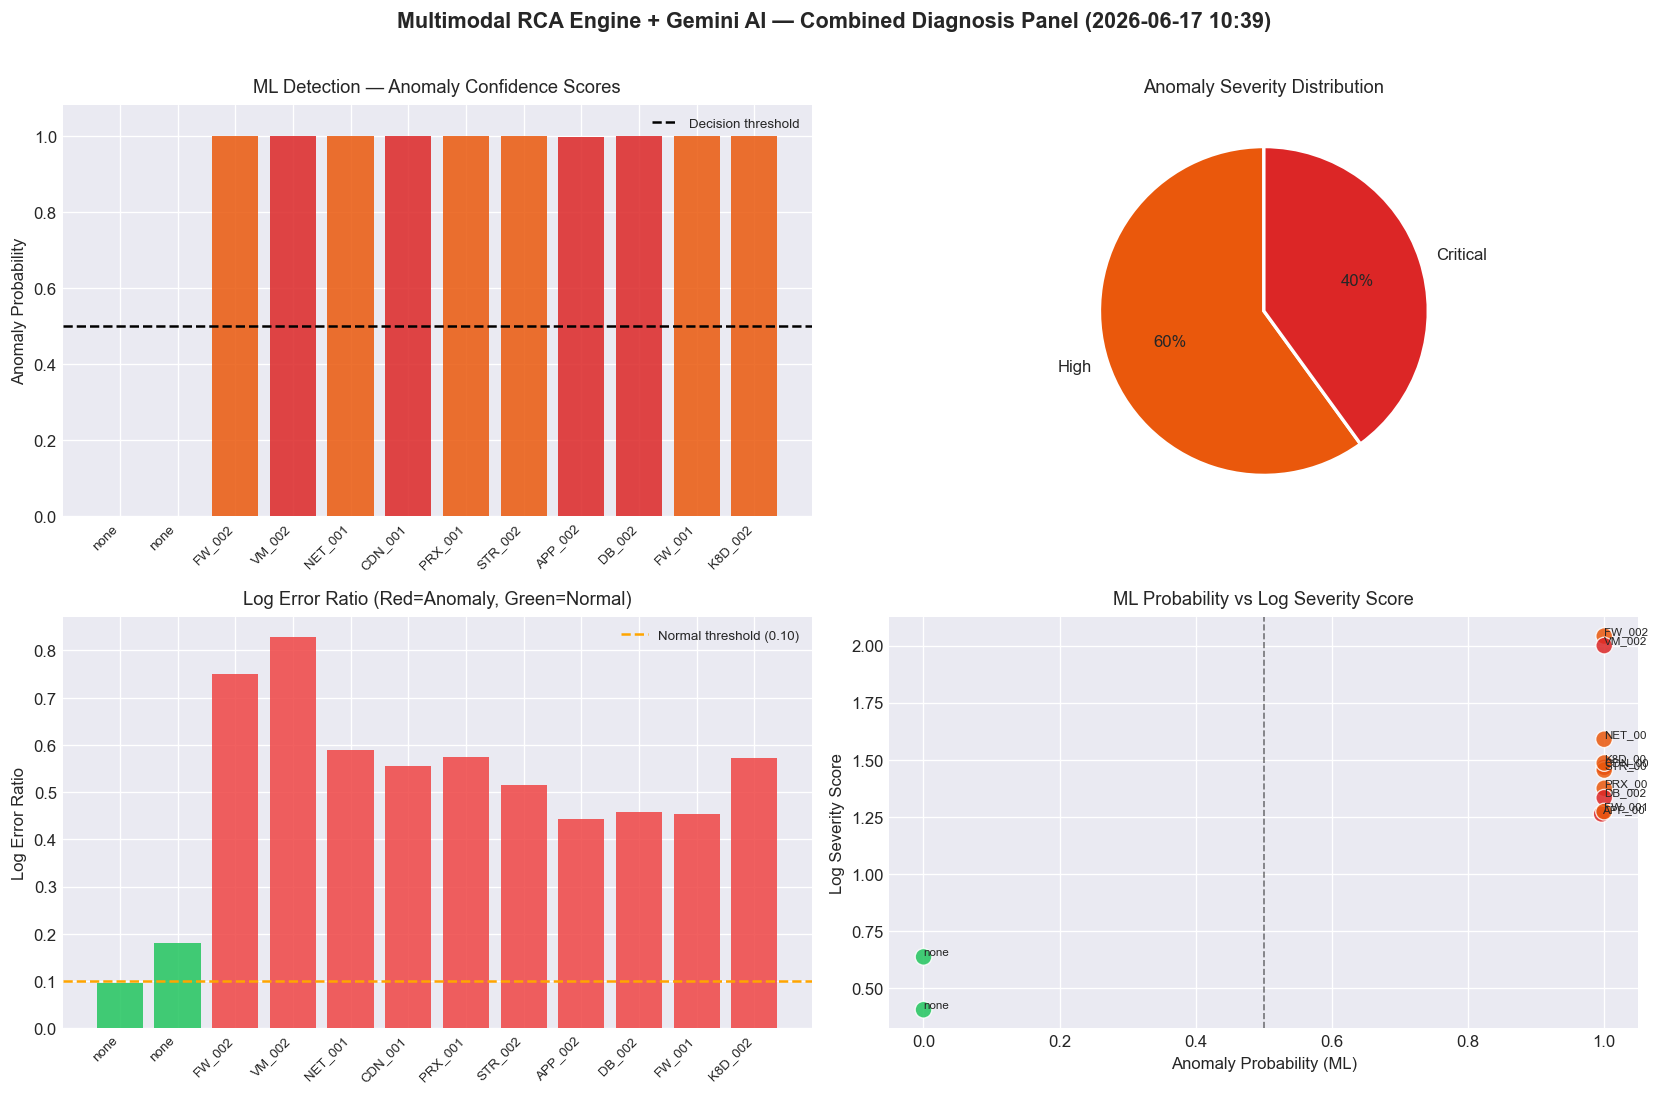

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sev_colors = {
    'critical': '#dc2626', 'high': '#ea580c',
    'medium': '#ca8a04', 'low': '#16a34a',
    'normal': '#22c55e', 'none': '#22c55e',
}

# A — Confidence score bar chart
ax = axes[0, 0]
probs  = [r['prob_anomaly'] for r in results]
colors = [sev_colors.get(r['severity'], '#22c55e') for r in results]
labels = [r['scenario_id'][:7] for r in results]
ax.bar(range(len(results)), probs, color=colors, alpha=0.85)
ax.axhline(0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold')
ax.set_xticks(range(len(results)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Anomaly Probability')
ax.set_ylim(0, 1.08)
ax.set_title('ML Detection — Anomaly Confidence Scores', fontsize=11, pad=8)
ax.legend(fontsize=8)

# B — Severity distribution
ax = axes[0, 1]
sev_data = defaultdict(int)
for r in results:
    if r['is_anomaly']:
        sev_data[r['severity']] += 1
sev_labels_en = {'critical': 'Critical', 'high': 'High', 'medium': 'Medium', 'low': 'Low'}
if sev_data:
    ax.pie(
        list(sev_data.values()),
        labels=[sev_labels_en.get(k,k) for k in sev_data.keys()],
        colors=[sev_colors.get(k,'#888') for k in sev_data.keys()],
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
ax.set_title('Anomaly Severity Distribution', fontsize=11, pad=8)

# C — Log error ratio comparison
ax = axes[1, 0]
err_ratios = [r['log_features'].get('log_error_ratio', 0) for r in results]
bar_colors = ['#ef4444' if r['is_anomaly'] else '#22c55e' for r in results]
ax.bar(range(len(results)), err_ratios, color=bar_colors, alpha=0.85)
ax.set_xticks(range(len(results)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Log Error Ratio')
ax.set_title('Log Error Ratio (Red=Anomaly, Green=Normal)', fontsize=11, pad=8)
ax.axhline(0.1, color='orange', linestyle='--', lw=1.5, label='Normal threshold (0.10)')
ax.legend(fontsize=8)

# D — Severity score scatter
ax = axes[1, 1]
sev_scores = [r['log_features'].get('log_severity_score', 0) for r in results]
ax.scatter(
    [r['prob_anomaly'] for r in results],
    sev_scores,
    c=[sev_colors.get(r['severity'],'#22c55e') for r in results],
    s=100, alpha=0.85, edgecolors='white', linewidths=0.8
)
for i, r in enumerate(results):
    ax.annotate(r['scenario_id'][:6], (r['prob_anomaly'], sev_scores[i]),
                fontsize=7, ha='left', va='bottom')
ax.set_xlabel('Anomaly Probability (ML)')
ax.set_ylabel('Log Severity Score')
ax.set_title('ML Probability vs Log Severity Score', fontsize=11, pad=8)
ax.axvline(0.5, color='black', linestyle='--', lw=1, alpha=0.5)

fig.suptitle(
    f'Multimodal RCA Engine + Gemini AI — Combined Diagnosis Panel '
    f'({datetime.now().strftime("%Y-%m-%d %H:%M")})',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()